In [37]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
%matplotlib inline
import datetime
from astropy.time import Time

In [19]:
data = pd.read_csv("prez_dates.dat", delimiter="&", header=None, usecols=[0,1,2])

In [20]:
data

,0,1,2
0,1,George Washington,"December 14, 1799"
1,2,Thomas Jefferson,"July 4, 1826"
2,3,John Adams,"July 4, 1826"
3,4,James Monroe,"July 4, 1831"
4,5,James Madison,"June 28, 1836"
5,6,William Henry Harrison[d],"April 4, 1841"
6,7,Andrew Jackson,"June 8, 1845"
7,8,John Quincy Adams,"February 23, 1848"
8,9,James K. Polk,"June 15, 1849"
9,10,Zachary Taylor[d],"July 9, 1850"


In [31]:
dts = [datetime.datetime.strptime(val.strip().replace(",", ""), '%B %d %Y') for val in data[2]]

Text(0, 0.5, 'Number of Presidential Deaths')

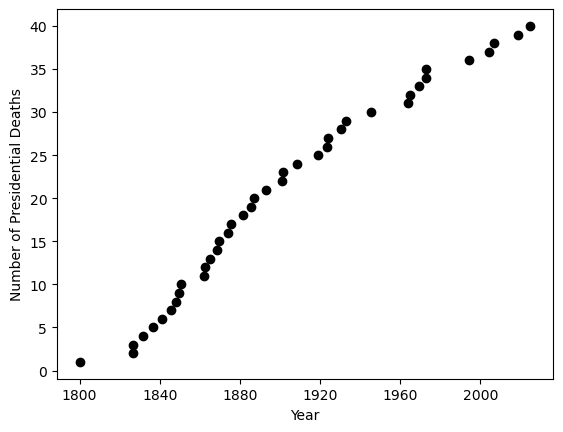

In [35]:
fig, ax = plt.subplots()
ax.plot(dts, np.cumsum(np.ones(len(dts))), 'ko')
ax.set_xlabel("Year")
ax.set_ylabel("Number of Presidential Deaths")

In [41]:
astropy_times = Time(dts)

In [44]:
mjds = astropy_times.mjd
gap = 30 *365.25
deaths_in_last_n = []
for mjd in mjds:
    in_range = np.where((mjds <= mjd) & (mjds > mjd-gap))[0]
    deaths_in_last_n.append(in_range.size)

Text(0, 0.5, 'Number of Presidential Deaths in last 30 years')

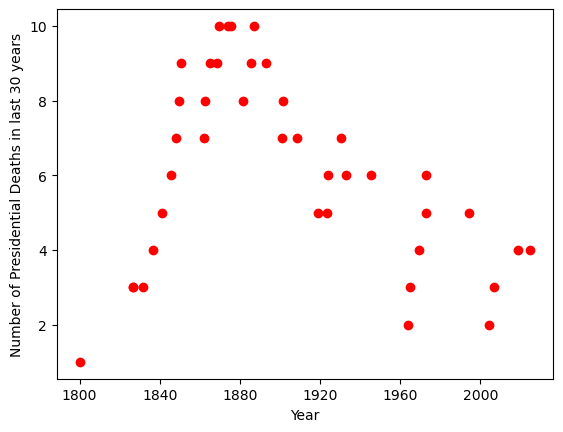

In [48]:
fig, ax = plt.subplots()
ax.plot(dts, deaths_in_last_n, 'ro')
ax.set_xlabel("Year")
ax.set_ylabel("Number of Presidential Deaths in last 30 years")